In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load the data
try:
    df = pd.read_json('logins.json')
    print("Data loaded successfully.")
except Exception as e:
    print(f"Error loading data: {e}")
df

Data loaded successfully.


,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21
...,...
93137,1970-04-13 18:50:19
93138,1970-04-13 18:43:56
93139,1970-04-13 18:54:02
93140,1970-04-13 18:57:38


In [3]:
# 2. Data Quality Check & Preparation
# Convert to datetime if not already
df['login_time'] = pd.to_datetime(df['login_time'])
df

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21
...,...
93137,1970-04-13 18:50:19
93138,1970-04-13 18:43:56
93139,1970-04-13 18:54:02
93140,1970-04-13 18:57:38


In [4]:
# Check for missing values
missing_count = df.isnull().sum().sum()
print(f"Missing values: {missing_count}")

Missing values: 0


In [5]:
# Add a counter column for resampling
df['count'] = 1
df.set_index('login_time', inplace=True)
df.sort_index(inplace=True)
df

,count
login_time,
1970-01-01 20:12:16,1
1970-01-01 20:13:18,1
1970-01-01 20:16:10,1
1970-01-01 20:16:36,1
1970-01-01 20:16:37,1
...,...
1970-04-13 18:48:52,1
1970-04-13 18:50:19,1
1970-04-13 18:54:02,1


In [6]:
# 3. Aggregate into 15-minute intervals
df_15 = df.resample('15T').sum()
df_15

/tmp/ipykernel_73187/2442109691.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_15 = df.resample('15T').sum()


,count
login_time,
1970-01-01 20:00:00,2
1970-01-01 20:15:00,6
1970-01-01 20:30:00,9
1970-01-01 20:45:00,7
1970-01-01 21:00:00,1
...,...
1970-04-13 17:45:00,5
1970-04-13 18:00:00,5
1970-04-13 18:15:00,2


# Time Series Analysis

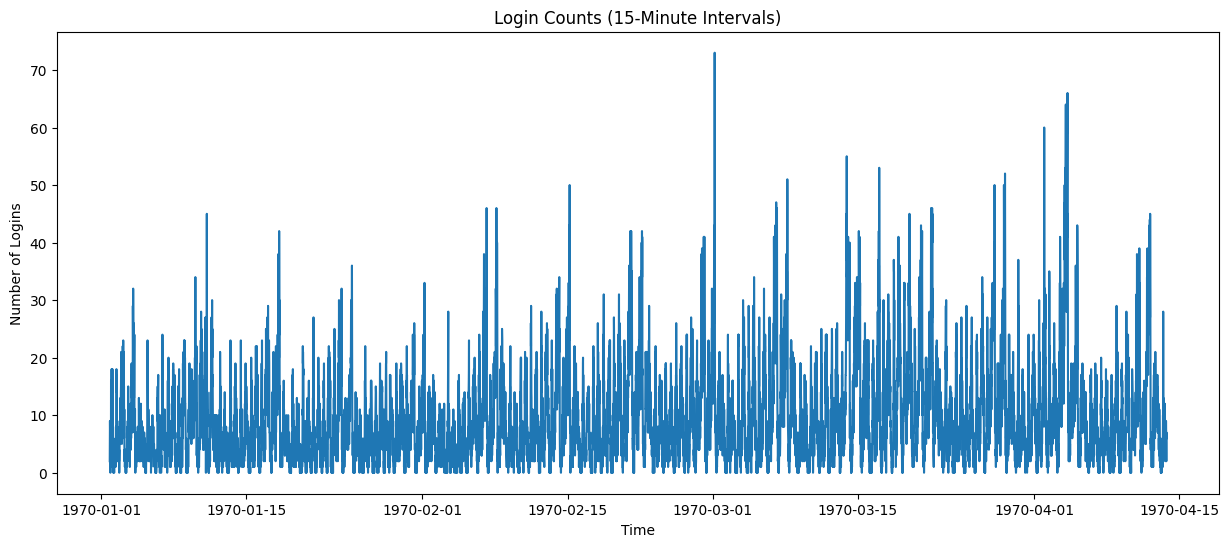

In [7]:
# 4. Visualization & Feature Extraction
plt.figure(figsize=(15, 6))
plt.plot(df_15.index, df_15['count'])
plt.title('Login Counts (15-Minute Intervals)')
plt.xlabel('Time')
plt.ylabel('Number of Logins')
plt.show()

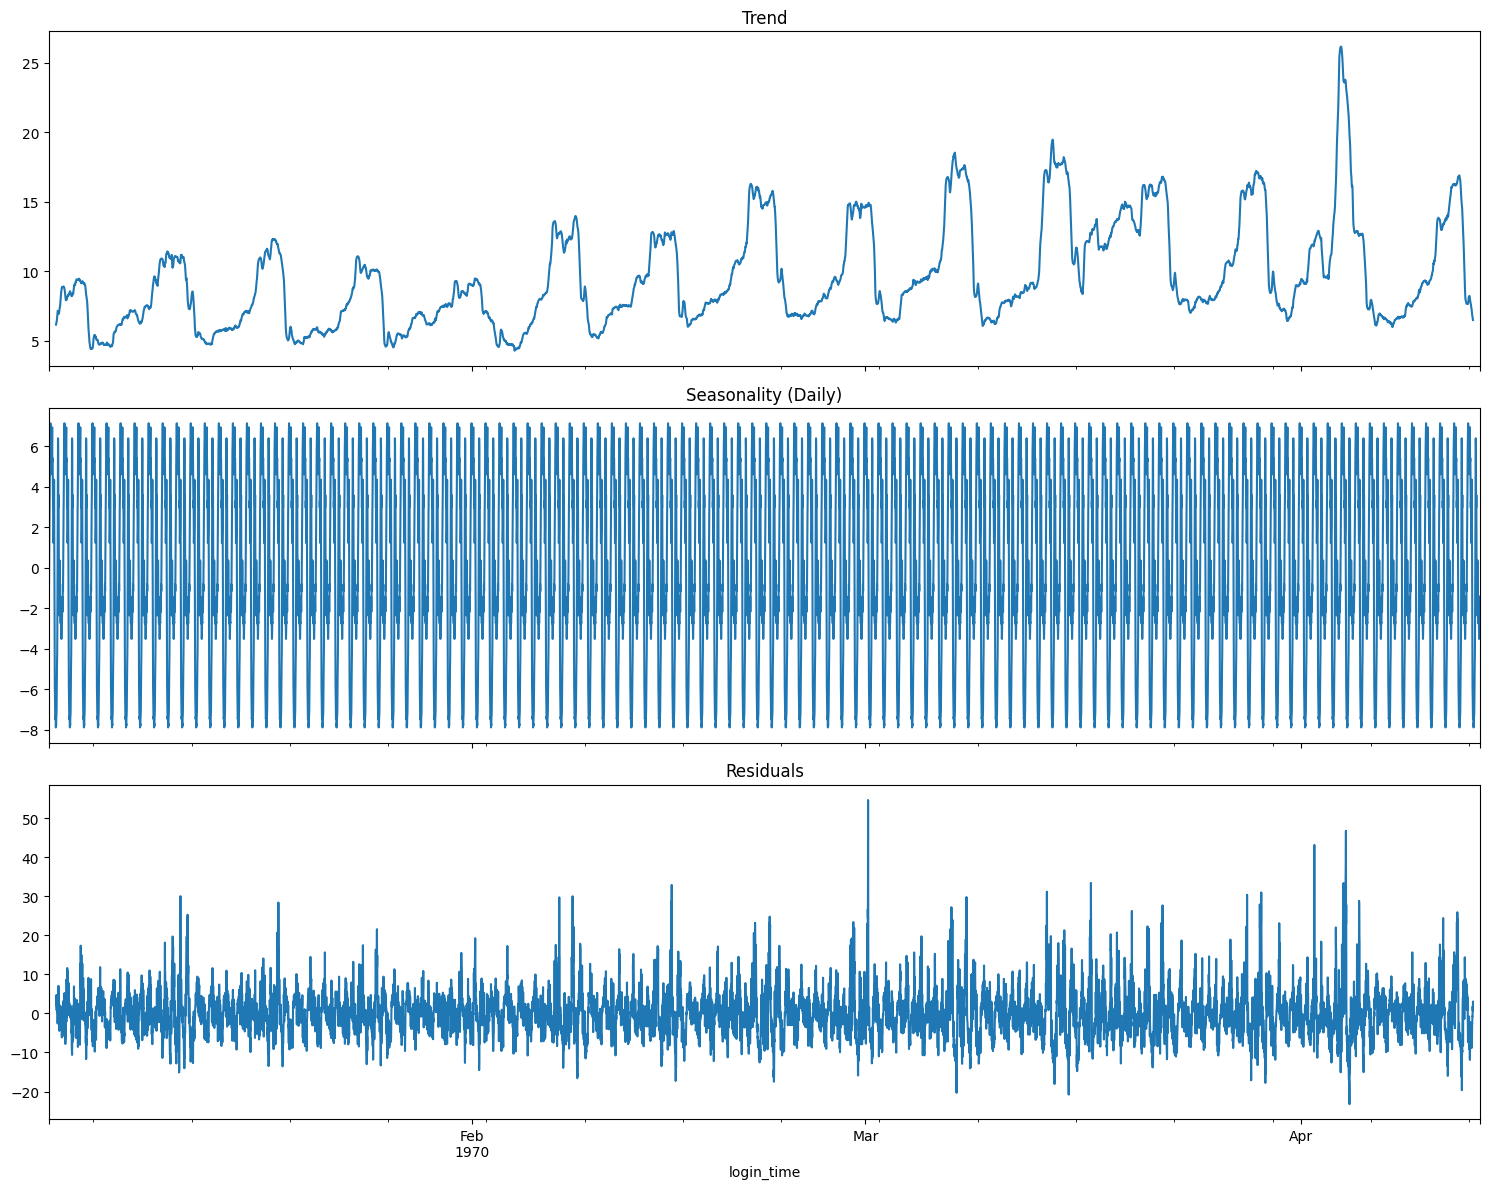

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pandas.plotting import lag_plot

# 1. Seasonal Decomposition (Daily cycle = 24 hours * 4 intervals/hr = 96)
# We'll look at a subset (e.g., first 2 weeks) to see the daily patterns clearly
decomposition = seasonal_decompose(df_15['count'], model='additive', period=96)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
decomposition.trend.plot(ax=ax1, title='Trend')
decomposition.seasonal.plot(ax=ax2, title='Seasonality (Daily)')
decomposition.resid.plot(ax=ax3, title='Residuals')
plt.tight_layout()
plt.show()

In [9]:
# 2. Augmented Dickey-Fuller Test for Stationarity
print("--- Augmented Dickey-Fuller Test ---")
adf_result = adfuller(df_15['count'])
print(f'ADF Statistic: {adf_result[0]:.3f}')
print(f'p-value: {adf_result[1]:.3f}')
if adf_result[1] < 0.05:
    print("Result: The series is likely stationary (reject null hypothesis).")
else:
    print("Result: The series is non-stationary (fail to reject null hypothesis).")


--- Augmented Dickey-Fuller Test ---
ADF Statistic: -10.338
p-value: 0.000
Result: The series is likely stationary (reject null hypothesis).


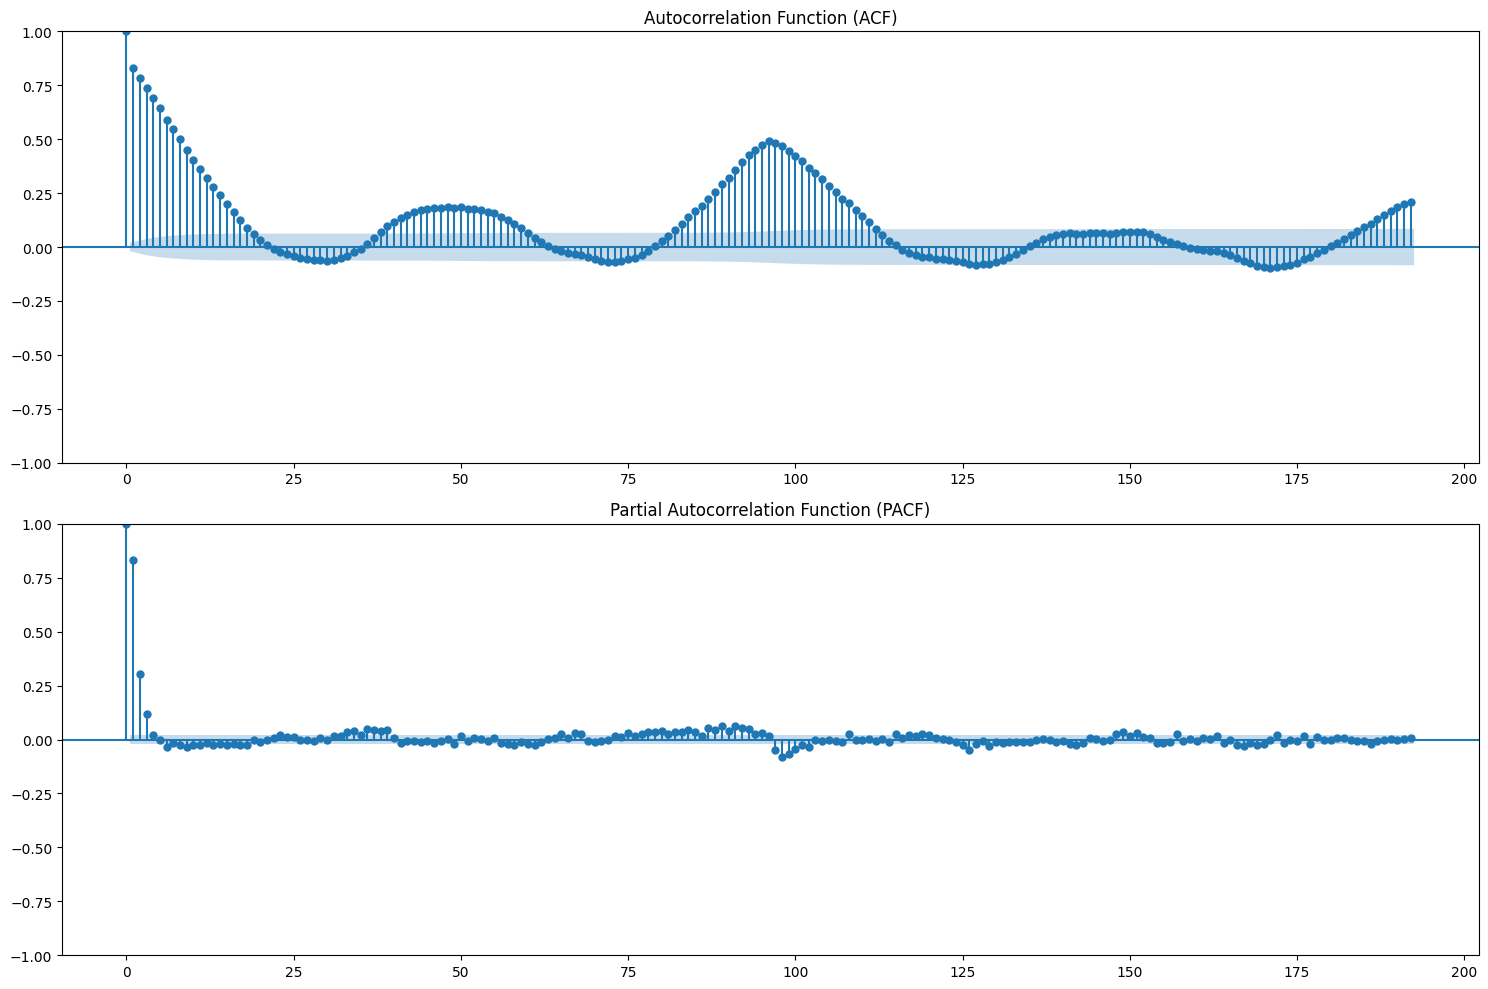

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set the number of lags to show (e.g., 2 days = 2 * 96 = 192)
lags = 192

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# ACF Plot
plot_acf(df_15['count'], lags=lags, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# PACF Plot
plot_pacf(df_15['count'], lags=lags, ax=ax2, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

The mild correlation at lag ~48 (12 hours) and stronger correlation at lag 96 (24 hours) corresponds well with the bimodal daily cycle below.

# Daily cycle

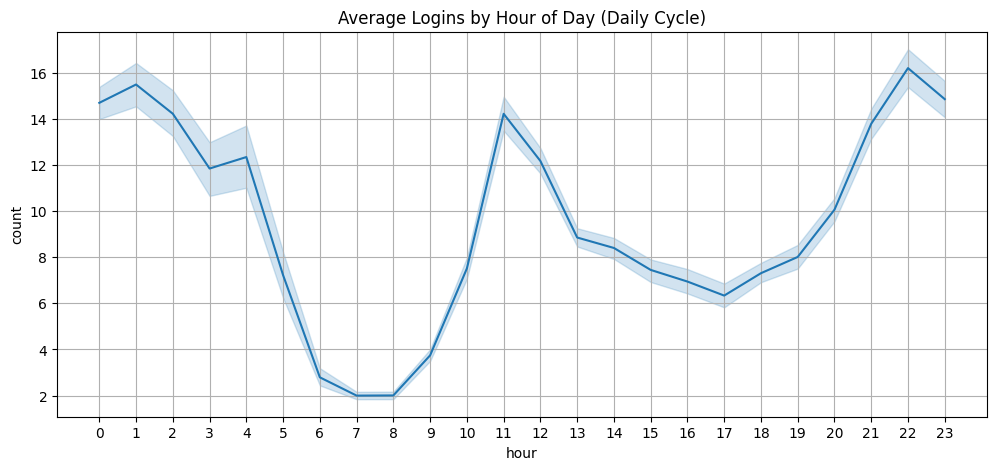

In [11]:
# Daily cycle visualization (Average logins by hour of day)
df_15['hour'] = df_15.index.hour
df_15['day_of_week'] = df_15.index.day_name()

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_15, x='hour', y='count')
plt.title('Average Logins by Hour of Day (Daily Cycle)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

Average logins by hour of day shows a very consistent pattern: a bimodal distribution, with peaks during the late night (10 PM – 2 AM) and around noon. The 95% confidence interval hugs the line tightly throughout the ups and downs, so we can be confident that the pattern is real.

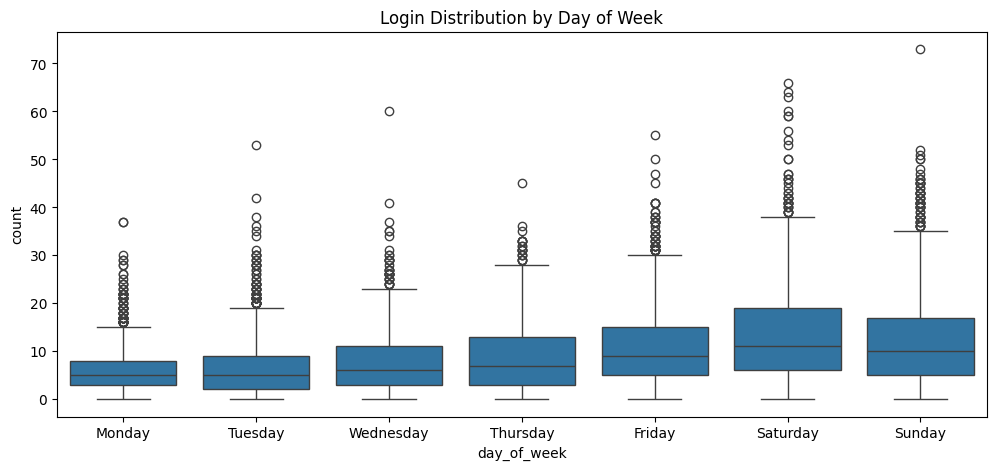

Analysis Summary:
1. Data spans from 1970-01-01 20:00:00 to 1970-04-13 18:45:00
2. Check the daily cycle plot for peak hours (e.g., late night vs mid-day).
3. Check the boxplot for weekend vs weekday demand variations.


In [12]:
# Weekly cycle visualization
plt.figure(figsize=(12, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df_15, x='day_of_week', y='count', order=day_order)
plt.title('Login Distribution by Day of Week')
plt.show()

print("Analysis Summary:")
print("1. Data spans from", df_15.index.min(), "to", df_15.index.max())
print("2. Check the daily cycle plot for peak hours (e.g., late night vs mid-day).")
print("3. Check the boxplot for weekend vs weekday demand variations.")

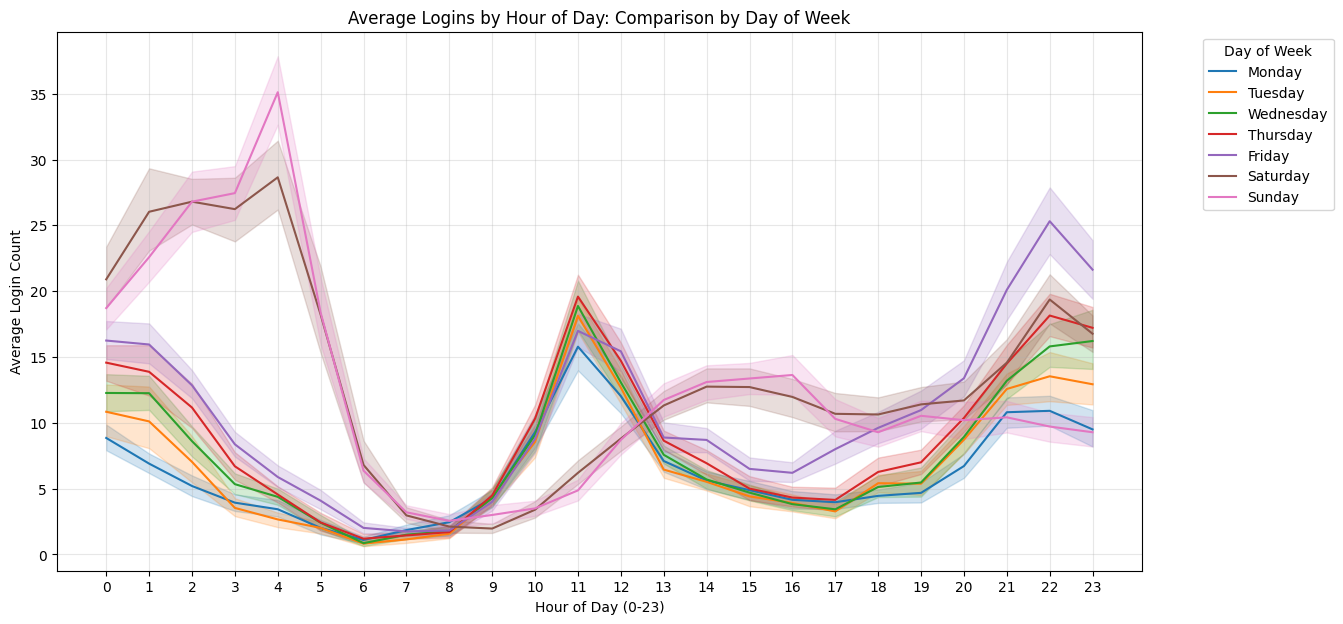

In [13]:
# Average logins by hour of day for every day of the week
plt.figure(figsize=(14, 7))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.lineplot(data=df_15, x='hour', y='count', hue='day_of_week', hue_order=day_order)

plt.title('Average Logins by Hour of Day: Comparison by Day of Week')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Login Count')
plt.xticks(range(0, 24))
plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

*   Weekday follows consistent bimodal pattern (close to the daily cycle) throughout the day, only diverging in the last quarter of the day.
*   Weekend follows a noticeably different pattern (lots of activity in the first quarter of the day), but also consistent until diverging in the last 4 hours of the day (Sunday levels off, while Saturday spikes)
*   Lowest activity is consistently around 8 AM
*   In the last 4 hours of the day, least to most activity: Sunday, Monday, Tuesday, Wednesday, Thursday, Saturday, Friday